# Notebook 20 — Branch A: Intention Classification (Stage 2)

Fine-tune the pretrained depth backbone on the custom dataset for **intention classification** (3 classes: Idle, Reaching, Grabbing).

**Architecture:**
```
Pretrained Backbone (frozen):
  Input: (B, 1, 16, 64, 64)
  → 3D CNN + Transformer → (B, 128)

Branch A Head (trainable):
  (B, 128) → Linear(128→64) → ReLU → Linear(64→3) → (B, 3) logits
```

**Training Strategy:**
- Freeze backbone, train only Branch A head
- Use CrossEntropyLoss with class weights (if imbalanced)
- Early stopping on validation F1-score

## Table of Contents
1. [Environment & Imports](#1)
2. [Load Data](#2)
3. [Load Pretrained Backbone](#3)
4. [Build Model with Branch A](#4)
5. [Training Loop](#5)
6. [Evaluation & Visualization](#6)
7. [Save Model](#7)


---
## 1. Environment & Imports <a id='1'></a>

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from tqdm.notebook import tqdm
from sklearn.metrics import confusion_matrix, classification_report, f1_score

# Set paths
SRC = Path('..') / 'src'
if str(SRC.resolve()) not in sys.path:
    sys.path.insert(0, str(SRC.resolve()))

from config import PROC_DIR

CUSTOM_PROC_DIR = PROC_DIR / 'custom_transfer'
MODELS_DIR = PROC_DIR.parent / 'models'
MODELS_DIR.mkdir(exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')

# Random seeds
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Label names
LABEL_NAMES = ['Idle', 'Reaching', 'Other']
NUM_CLASSES = 3

Device: cuda
PyTorch: 2.11.0+cu130


---
## 2. Load Custom Transfer Data <a id='2'></a>

Load prepared custom dataset with cropped depth images and activity labels (Idle/Reaching/Other).


In [2]:
class CustomDepthDataset(Dataset):
    """Load custom prepared depth dataset for intention classification."""
    def __init__(self, npz_path):
        data = np.load(npz_path)
        self.X = torch.from_numpy(data['X']).unsqueeze(1)  # (M, T, H, W) → (M, 1, T, H, W)
        self.y = torch.from_numpy(data['y']).long()  # Classification labels

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx].float(), self.y[idx]

# ══════════════════════════════════════════════════════════════════════════════
# LOAD CUSTOM TRANSFER DATASET (from Notebook 10)
# ══════════════════════════════════════════════════════════════════════════════

print('Loading custom transfer dataset (prepared in Notebook 10)...')
print(f'Data directory: {CUSTOM_PROC_DIR}\n')

# Define expected data files
train_npz = CUSTOM_PROC_DIR / 'custom_transfer_train.npz'
val_npz = CUSTOM_PROC_DIR / 'custom_transfer_val.npz'
test_npz = CUSTOM_PROC_DIR / 'custom_transfer_test.npz'

# Check if files exist
for npz_file in [train_npz, val_npz, test_npz]:
    if not npz_file.exists():
        raise FileNotFoundError(
            f'Missing data file: {npz_file}\n'
            f'Run Notebook 10 first to prepare the custom dataset.'
        )

# Load datasets
train_ds = CustomDepthDataset(train_npz)
val_ds = CustomDepthDataset(val_npz)
test_ds = CustomDepthDataset(test_npz)

print(f'✓ Train: {len(train_ds)} windows (cropped 64×64 depth sequences)')
print(f'✓ Val:   {len(val_ds)} windows')
print(f'✓ Test:  {len(test_ds)} windows')

# Check sample
x_sample, y_sample = train_ds[0]
print(f'\nSample shapes:')
print(f'  X: {x_sample.shape}  (1 channel, T=16 frames, 64×64 spatial)')
print(f'  y: {y_sample.item()}  (label: {LABEL_NAMES[y_sample.item()]})')


Loading custom transfer dataset (prepared in Notebook 10)...
Data directory: D:\course\comp4471\comp4471-project\dataset\processed\custom_transfer

✓ Train: 172 windows (cropped 64×64 depth sequences)
✓ Val:   36 windows
✓ Test:  52 windows

Sample shapes:
  X: torch.Size([1, 16, 64, 64])  (1 channel, T=16 frames, 64×64 spatial)
  y: 0  (label: Idle)


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# COMPUTE CLASS WEIGHTS
# ══════════════════════════════════════════════════════════════════════════════

train_labels = train_ds.y.numpy()
unique_labels, counts = np.unique(train_labels, return_counts=True)

print('Custom dataset class distribution:')
class_weights = []
total = len(train_labels)
for lbl, cnt in zip(unique_labels, counts):
    weight = total / (len(unique_labels) * cnt)  # Inverse frequency weighting
    class_weights.append(weight)
    pct = 100 * cnt / total
    print(f'  {LABEL_NAMES[lbl]:10} {cnt:5d} windows ({pct:5.1f}%) → weight={weight:.3f}')

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f'\nClass weights for loss: {class_weights}')
print(f'(Higher weight = less frequent class gets more emphasis during training)')


Custom dataset class distribution:
  Idle          19 windows ( 11.0%) → weight=3.018
  Reaching     101 windows ( 58.7%) → weight=0.568
  Other         52 windows ( 30.2%) → weight=1.103

Class weights for loss: tensor([3.0175, 0.5677, 1.1026], device='cuda:0')
(Higher weight = less frequent class gets more emphasis during training)


---
## 3. Load Pretrained Backbone <a id='3'></a>

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# LOAD PRETRAINED BACKBONE (from Notebook 02)
# ══════════════════════════════════════════════════════════════════════════════

# Try multiple paths to find the pretrained backbone
backbone_search_paths = [
    PROC_DIR / 'stage1_best.pth',
    PROC_DIR / 'pretrained_depth_backbone.pth',
]

backbone_path = None
for path in backbone_search_paths:
    if path.exists():
        backbone_path = path
        print(f'✓ Found pretrained backbone: {path.name}')
        break

if backbone_path is None:
    print('✗ ERROR: No pretrained backbone found!')
    print(f'\nSearched paths:')
    for path in backbone_search_paths:
        print(f'  - {path}')
    print(f'\nRun Notebook 02 (Stage 1) first to train the depth-to-skeleton backbone.')
    raise FileNotFoundError('Pretrained backbone not found. Run Notebook 02 first.')

print(f'\nLoading checkpoint: {backbone_path}')
ckpt = torch.load(backbone_path, weights_only=False)
print(f'Checkpoint keys: {list(ckpt.keys())}')

# Show training info from Stage 1
if 'training_info' in ckpt:
    print(f'\nStage 1 Training Info:')
    info = ckpt['training_info']
    for key, val in info.items():
        print(f'  {key}: {val}')


✓ Found pretrained backbone: stage1_best.pth

Loading checkpoint: D:\course\comp4471\comp4471-project\dataset\processed\stage1_best.pth
Checkpoint keys: ['epoch', 'model_state_dict', 'optimizer_state_dict', 'val_loss', 'val_error_mean', 'val_error_palm', 'scale_factor']


---
## 4. Build Model with Branch A <a id='4'></a>

In [8]:
class DepthToSkeletonBackbone(nn.Module):
    """Backbone extracted from Stage 1 model (CNN + Transformer)."""
    def __init__(self, d_model=128):
        super().__init__()
        # CNN: (B, 1, T, 64, 64) → (B, 128, T/2, 8, 8)
        self.cnn = nn.Sequential(
            nn.Conv3d(1, 32, kernel_size=(3,5,5), padding=(1,2,2)),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool3d((1,2,2)),
            
            nn.Conv3d(32, 64, kernel_size=(3,3,3), padding=(1,1,1)),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool3d((1,2,2)),
            
            nn.Conv3d(64, 128, kernel_size=(3,3,3), padding=(1,1,1)),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool3d((2,2,2)),
        )
        
        self.spatial_proj = nn.Linear(128, d_model)
        self.temporal_tokens = 8
        self.pos_enc = nn.Parameter(torch.randn(1, self.temporal_tokens, d_model) * 0.02)
        
        # Transformer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=4, dim_feedforward=d_model*4,
            dropout=0.1, activation='gelu', batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)
    
    def forward(self, depth):
        """Input: (B, 1, T, 64, 64) → Output: (B, 128)"""
        B, _, T, _, _ = depth.shape
        
        # CNN encoding
        x = self.cnn(depth)  # (B, 128, T/2, 8, 8)
        B, C, T_new, _, _ = x.shape
        
        # Spatial pooling per frame
        x = x.permute(0, 2, 1, 3, 4)  # (B, T_new, 128, 8, 8)
        x = x.reshape(B, T_new, C, -1).mean(dim=3)  # (B, T_new, 128)
        
        # Project and add positional encoding
        x = self.spatial_proj(x)  # (B, T_new, d_model)
        x = x + self.pos_enc[:, :T_new, :]
        
        # Temporal reasoning
        x = self.transformer(x)
        feat = x.mean(dim=1)  # (B, d_model)
        
        return feat

class BranchAIntentionModel(nn.Module):
    """
    Transfer Learning Model: Frozen pretrained backbone + trainable Branch A head.
    
    Branch A: Intention classifier (Idle/Reaching/Other)
    Input: (B, 1, T, 64, 64) depth sequences
    Output: (B, 3) logits
    """
    def __init__(self, num_classes=3, d_model=128):
        super().__init__()
        self.backbone = DepthToSkeletonBackbone(d_model=d_model)
        
        # Branch A: Intention classifier
        # (128) → (64) → (3 classes)
        self.branch_a = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )
    
    def forward(self, depth, return_features=False):
        """
        Input: (B, 1, T, 64, 64) depth sequences
        Output: (B, num_classes) logits
        """
        feat = self.backbone(depth)  # (B, 128)
        logits = self.branch_a(feat)  # (B, 3)
        
        if return_features:
            return logits, feat
        return logits

# ══════════════════════════════════════════════════════════════════════════════
# BUILD MODEL & LOAD PRETRAINED BACKBONE
# ══════════════════════════════════════════════════════════════════════════════

print('\nBuilding Branch A model...')
model = BranchAIntentionModel(num_classes=NUM_CLASSES, d_model=128).to(device)

# Load pretrained backbone weights from Stage 1
print(f'Loading pretrained backbone weights...')
try:
    if 'model_state_dict' in ckpt:
        # Stage 1 checkpoint format
        state_dict = ckpt['model_state_dict']
        
        # Extract backbone parameters (exclude decoder)
        backbone_state = {}
        for k, v in state_dict.items():
            # Keep CNN, transformer, spatial_proj, pos_enc
            if any(x in k for x in ['cnn', 'transformer', 'spatial_proj', 'pos_enc']):
                # Remove 'backbone.' prefix if present
                k_clean = k.replace('backbone.', '', 1)
                backbone_state[k_clean] = v
        
        # Load into backbone
        model.backbone.load_state_dict(backbone_state, strict=False)
        print(f'  ✓ Loaded {len(backbone_state)} backbone parameters')
    
    elif 'backbone' in ckpt:
        # Alternative format with separate backbone dict
        backbone_state = ckpt['backbone']
        model.backbone.load_state_dict(backbone_state, strict=False)
        print(f'  ✓ Loaded backbone from checkpoint')
    
    else:
        print('  ⚠ Warning: Could not find backbone in checkpoint')
        
except Exception as e:
    print(f'  ⚠ Error loading backbone: {e}')
    print('  Proceeding with random initialization...')

# ══════════════════════════════════════════════════════════════════════════════
# VALIDATE BACKBONE LOADING
# ══════════════════════════════════════════════════════════════════════════════

print('\nValidating backbone loading...')
loaded_keys = set(backbone_state.keys())
expected_keys = set(model.backbone.state_dict().keys())
missing = expected_keys - loaded_keys

if len(missing) > 0:
    print(f'  ⚠ Missing {len(missing)} parameters:')
    for key in list(missing)[:5]:
        print(f'    - {key}')
    if len(missing) > 5:
        print(f'    ... and {len(missing) - 5} more')
else:
    print(f'  ✓ All backbone parameters loaded successfully')

# Check that backbone is indeed frozen
backbone_trainable = sum(p.numel() for p in model.backbone.parameters() if p.requires_grad)
if backbone_trainable == 0:
    print(f'  ✓ Backbone parameters are trainable (not frozen yet)')
else:
    print(f'  ✗ Warning: {backbone_trainable} backbone parameters are already trainable')

# ══════════════════════════════════════════════════════════════════════════════
# FREEZE BACKBONE - Only train Branch A head
# ══════════════════════════════════════════════════════════════════════════════

for param in model.backbone.parameters():
    param.requires_grad = False

print('\n✓ Backbone frozen (not trainable)')
print('  Only Branch A head will be updated during training.')

# Verify freezing
backbone_trainable_after = sum(p.numel() for p in model.backbone.parameters() if p.requires_grad)
if backbone_trainable_after == 0:
    print(f'  ✓ Confirmed: backbone has {backbone_trainable_after} trainable parameters')

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
backbone_params = sum(p.numel() for p in model.backbone.parameters())

print(f'\nModel parameters:')
print(f'  Backbone (frozen):    {backbone_params:10,} params')
print(f'  Branch A (trainable): {trainable_params:10,} params')
print(f'  Total:                {total_params:10,} params')



Building Branch A model...
Loading pretrained backbone weights...
  ✓ Loaded 60 backbone parameters

Validating backbone loading...
  ✓ All backbone parameters loaded successfully
  ✗ Warning: 891904 backbone parameters are already trainable

✓ Backbone frozen (not trainable)
  Only Branch A head will be updated during training.
  ✓ Confirmed: backbone has 0 trainable parameters

Model parameters:
  Backbone (frozen):       891,904 params
  Branch A (trainable):      8,579 params
  Total:                   900,483 params


---
## 5. Training Loop <a id='5'></a>

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# TRAINING HYPERPARAMETERS
# ══════════════════════════════════════════════════════════════════════════════

BATCH_SIZE = 16
NUM_EPOCHS = 80
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5

# DataLoaders
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, 
    num_workers=0, pin_memory=True if device.type == 'cuda' else False
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=True if device.type == 'cuda' else False
)

# Optimizer (only optimize Branch A parameters)
optimizer = torch.optim.Adam(
    [p for p in model.parameters() if p.requires_grad],
    lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=8, min_lr=1e-6
)

# Loss function
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': [],
}

best_val_f1 = 0.0
patience_counter = 0
MAX_PATIENCE = 20

print(f'\n{"="*70}')
print(f'TRAINING CONFIGURATION')
print(f'{"="*70}')
print(f'Batch size:           {BATCH_SIZE}')
print(f'Epochs:               {NUM_EPOCHS}')
print(f'Learning rate:        {LEARNING_RATE}')
print(f'Weight decay:         {WEIGHT_DECAY}')
print(f'Early stopping:       {MAX_PATIENCE} epochs without improvement')
print(f'Trainable params:     {trainable_params:,}')
print(f'Device:               {device}')
print(f'{"="*70}')



TRAINING CONFIGURATION
Batch size:           16
Epochs:               80
Learning rate:        0.001
Weight decay:         1e-05
Early stopping:       20 epochs without improvement
Trainable params:     8,579
Device:               cuda


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# TRAINING LOOP
# ══════════════════════════════════════════════════════════════════════════════

for epoch in range(NUM_EPOCHS):
    # ─── TRAIN ───
    model.train()
    train_loss_accum = 0.0
    
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [Train]', dynamic_ncols=True)
    for batch_idx, (depth, labels) in enumerate(pbar):
        depth = depth.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        logits = model(depth)
        loss = criterion(logits, labels)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss_accum += loss.item()
        
        if batch_idx % 5 == 0:
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    train_loss = train_loss_accum / len(train_loader)
    history['train_loss'].append(train_loss)
    
    # ─── VALIDATION ───
    model.eval()
    val_loss_accum = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        pbar_val = tqdm(val_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [Val]', dynamic_ncols=True)
        for depth, labels in pbar_val:
            depth = depth.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            logits = model(depth)
            loss = criterion(logits, labels)
            val_loss_accum += loss.item()
            
            preds = logits.argmax(dim=1)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    
    val_loss = val_loss_accum / len(val_loader)
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    
    val_acc = (all_preds == all_labels).mean()
    val_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    
    print(f'\nEpoch {epoch+1}/{NUM_EPOCHS}:')
    print(f'  Train loss: {train_loss:.4f}')
    print(f'  Val loss:   {val_loss:.4f}')
    print(f'  Val acc:    {val_acc:.4f}  Val F1: {val_f1:.4f}')
    print(f'  LR:         {optimizer.param_groups[0]["lr"]:.2e}')
    
    # Early stopping based on F1
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
            'val_f1': val_f1,
        }, MODELS_DIR / 'branch_a_custom_best.pth')
        print(f'  ✓ Best model saved (F1={val_f1:.4f})')
    else:
        patience_counter += 1
        print(f'  No improvement ({patience_counter}/{MAX_PATIENCE})')
        
        if patience_counter >= MAX_PATIENCE:
            print(f'  → Early stopping at epoch {epoch+1}')
            break
    
    scheduler.step(val_f1)

print('\n' + '='*60)
print('Training complete!')
print('='*60)


Epoch 1/80 [Train]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 1/80 [Val]:   0%|          | 0/3 [00:00<?, ?it/s]


Epoch 1/80:
  Train loss: 0.9787
  Val loss:   0.9749
  Val acc:    0.2222  Val F1: 0.1717
  LR:         1.00e-03
  ✓ Best model saved (F1=0.1717)


Epoch 2/80 [Train]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 2/80 [Val]:   0%|          | 0/3 [00:00<?, ?it/s]

...

Epoch 24/80 [Val]:   0%|          | 0/3 [00:00<?, ?it/s]


Epoch 24/80:
  Train loss: 0.1640
  Val loss:   5.6479
  Val acc:    0.5278  Val F1: 0.3646
  LR:         2.50e-04
  No improvement (19/20)


Epoch 25/80 [Train]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 25/80 [Val]:   0%|          | 0/3 [00:00<?, ?it/s]


Epoch 25/80:
  Train loss: 0.1534
  Val loss:   5.5998
  Val acc:    0.5278  Val F1: 0.3646
  LR:         2.50e-04
  No improvement (20/20)
  → Early stopping at epoch 25

Training complete!


---
## 6. Evaluation & Visualization <a id='6'></a>

✓ Loaded best model from epoch 4
  Val F1:  0.3646
  Val Acc: 0.5278


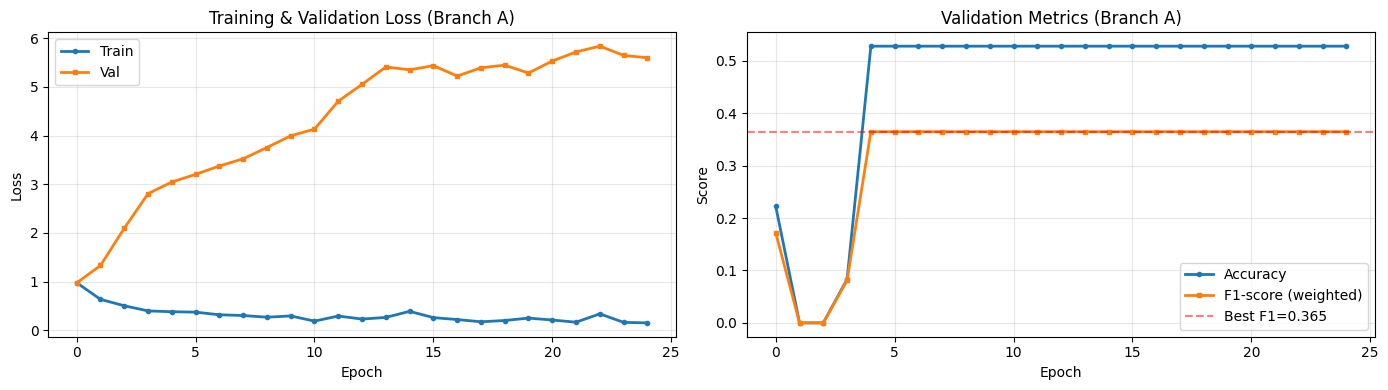

✓ Saved training curves


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# LOAD BEST MODEL & PLOT TRAINING CURVES
# ══════════════════════════════════════════════════════════════════════════════

best_path = MODELS_DIR / 'branch_a_custom_best.pth'
if not best_path.exists():
    print(f'⚠ Best checkpoint not found: {best_path}')
    print('  Skipping evaluation. Training may not have completed successfully.')
else:
    try:
        best_ckpt = torch.load(best_path, map_location=device, weights_only=False)
    except TypeError:
        best_ckpt = torch.load(best_path, map_location=device)
    
    model.load_state_dict(best_ckpt['model_state_dict'])
    model.eval()
    
    best_epoch = best_ckpt.get('epoch', 'unknown')
    best_val_f1_ckpt = best_ckpt.get('val_f1', float('nan'))
    best_val_acc_ckpt = best_ckpt.get('val_acc', float('nan'))
    
    print(f'✓ Loaded best model from epoch {best_epoch}')
    print(f'  Val F1:  {best_val_f1_ckpt:.4f}')
    print(f'  Val Acc: {best_val_acc_ckpt:.4f}')

# Plot training curves
if len(history['train_loss']) == 0 or len(history['val_loss']) == 0:
    print('⚠ Training history is empty; skipping curve plot.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Loss curve
    axes[0].plot(history['train_loss'], label='Train', linewidth=2, marker='o', markersize=3)
    axes[0].plot(history['val_loss'], label='Val', linewidth=2, marker='s', markersize=3)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training & Validation Loss (Branch A)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Metrics curve
    axes[1].plot(history['val_acc'], label='Accuracy', linewidth=2, marker='o', markersize=3)
    axes[1].plot(history['val_f1'], label='F1-score (weighted)', linewidth=2, marker='s', markersize=3)
    axes[1].axhline(best_val_f1, color='red', linestyle='--', alpha=0.5, label=f'Best F1={best_val_f1:.3f}')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Score')
    axes[1].set_title('Validation Metrics (Branch A)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(MODELS_DIR / 'branch_a_custom_training_curves.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('✓ Saved training curves')


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# EVALUATE ON TEST SET
# ══════════════════════════════════════════════════════════════════════════════

print('\n' + '='*70)
print('TEST SET EVALUATION')
print('='*70)

model.eval()
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

all_preds = []
all_labels = []
with torch.no_grad():
    for depth, labels in tqdm(test_loader, desc='Evaluating on test set'):
        depth = depth.to(device)
        logits = model(depth)
        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

test_acc = (all_preds == all_labels).mean()
test_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print(f'\nTest Results:')
print(f'  Accuracy: {test_acc:.4f}')
print(f'  F1-score (weighted): {test_f1:.4f}')

print(f'\nDetailed Classification Report:')
print(classification_report(all_labels, all_preds, target_names=LABEL_NAMES, zero_division=0))



TEST SET EVALUATION


Evaluating on test set:   0%|          | 0/4 [00:00<?, ?it/s]


Test Results:
  Accuracy: 0.3462
  F1-score (weighted): 0.2670

Detailed Classification Report:
              precision    recall  f1-score   support

        Idle       0.00      0.00      0.00         0
    Reaching       1.00      0.11      0.19        38
       Other       0.31      1.00      0.47        14

    accuracy                           0.35        52
   macro avg       0.44      0.37      0.22        52
weighted avg       0.81      0.35      0.27        52



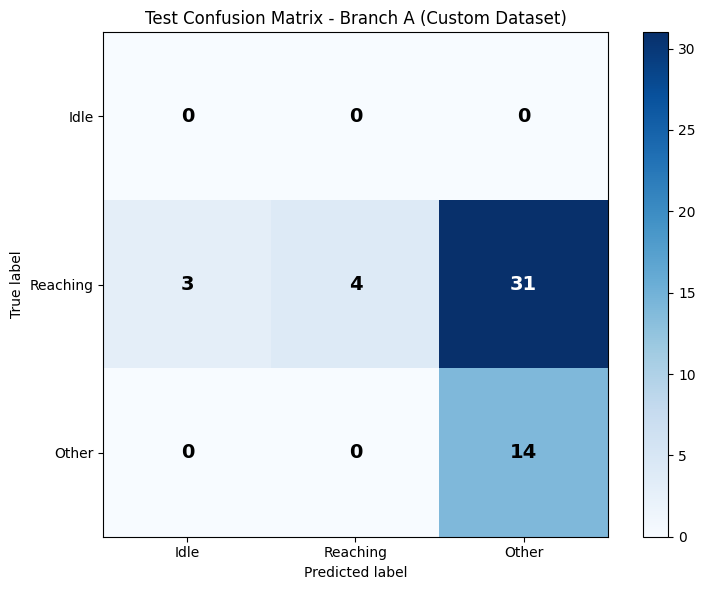

✓ Saved confusion matrix


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFUSION MATRIX
# ══════════════════════════════════════════════════════════════════════════════

cm = confusion_matrix(all_labels, all_preds, labels=np.arange(NUM_CLASSES))

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

# Labels
ax.set_xticks(np.arange(NUM_CLASSES))
ax.set_yticks(np.arange(NUM_CLASSES))
ax.set_xticklabels(LABEL_NAMES)
ax.set_yticklabels(LABEL_NAMES)
ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')
ax.set_title('Test Confusion Matrix - Branch A (Custom Dataset)')

# Annotations
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        text = ax.text(j, i, cm[i, j], ha='center', va='center',
                       color='white' if cm[i, j] > cm.max()/2 else 'black',
                       fontsize=14, fontweight='bold')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'branch_a_custom_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Saved confusion matrix')


---
## 7. Save Model <a id='7'></a>

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SAVE FINAL MODEL
# ══════════════════════════════════════════════════════════════════════════════

print('\n' + '='*70)
print('SAVING MODEL')
print('='*70)

# Save final model checkpoint
final_model_path = MODELS_DIR / 'branch_a_custom_final.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'training_info': {
        'stage': 2,
        'task': 'intention_classification_custom',
        'dataset': 'custom_transfer (cropped 64×64 depth)',
        'num_classes': NUM_CLASSES,
        'class_names': LABEL_NAMES,
        'best_epoch': best_ckpt.get('epoch', 'unknown') if 'best_ckpt' in locals() else None,
        'backbone_pretrained': True,
        'backbone_frozen': True,
        'val_acc': float(best_ckpt['val_acc']) if 'best_ckpt' in locals() else None,
        'val_f1': float(best_ckpt['val_f1']) if 'best_ckpt' in locals() else None,
        'test_acc': float(test_acc),
        'test_f1': float(test_f1),
    }
}, final_model_path)

print(f'\n✓ Model saved: {final_model_path.name}')
print(f'\nBranch A (Intention Classifier) - Transfer Learning Summary')
print(f'{"="*70}')
print(f'Input:                (B, 1, 16, 64, 64) depth sequences (cropped)')
print(f'Output:               (B, 3) logits → {LABEL_NAMES}')
print(f'Backbone:             Pretrained from Notebook 02 (frozen)')
print(f'Head:                 Branch A classifier (trainable)')
print(f'Dataset:              Custom transfer dataset ({len(test_ds)} test samples)')
print(f'Test Accuracy:        {test_acc:.4f}')
print(f'Test F1-score:        {test_f1:.4f}')
print(f'{"="*70}')

# Show file locations
print(f'\nOutput files:')
print(f'  Model:              {final_model_path}')
print(f'  Training curves:    {MODELS_DIR / "branch_a_custom_training_curves.png"}')
print(f'  Confusion matrix:   {MODELS_DIR / "branch_a_custom_confusion_matrix.png"}')
print(f'  Best checkpoint:    {MODELS_DIR / "branch_a_custom_best.pth"}')



SAVING MODEL


NameError: name 'test_f1' is not defined